In [2]:
%pip install cython

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
%load_ext Cython

In [2]:
import os
import numpy as np
import sys
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
plt.ion()

from utils import *
from parity_timestream import *

In [3]:
%matplotlib inline

In [4]:
import pyximport
pyximport.install()

(None, None)

In [5]:
from smurf_data_loader2 import *

In [6]:
sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")

In [7]:
print(os.getcwd())

/usr/local/src/pysmurf/scratch/adroster


In [8]:
%ls /data/smurf_data/20260413/1776119887/outputs/

1776120392_adc0.npy                    1776127669_single_channel_b0ch431.dat
1776120444.dat                         1776127698_single_channel_b0ch027.dat
1776120444_freq.txt                    1776128033_adc0.npy
1776120444_mask.txt                    1776128065_adc0.npy
1776122152_adc0.npy                    1776128079_adc0.npy
1776122172_single_channel_b0ch028.dat  1776128086_adc0.npy
1776122203_single_channel_b0ch259.dat  1776128112_adc0.npy
1776123405.dat                         1776128124_single_channel_b0ch367.dat
1776123405_freq.txt                    1776128153_single_channel_b0ch027.dat
1776123405_mask.txt                    1776128365_adc0.npy
1776124684_adc0.npy                    1776128370_single_channel_b0ch367.dat
1776124702_adc0.npy                    1776128398_single_channel_b0ch027.dat
1776125005.dat                         1776128457_adc0.npy
1776125005_freq.txt                    1776128470_single_channel_b0ch027.dat
1776125005_mask.txt                    177612852

In [9]:
data_filename = '/data/smurf_data/20260413/1776119887/outputs/1776128522.dat'

In [10]:
freq_data_filename = '/data/smurf_data/20260413/1776119887/outputs/1776128522_freq.txt'
freq_data = np.genfromtxt(freq_data_filename)

In [11]:
# %load /data/smurf_data/20260413/1776119887/outputs/1776128522_freq.txt
1009.2000
702.6000
5045.2000
4738.0000


4738.0

In [12]:
mask_data_filename = '/data/smurf_data/20260413/1776119887/outputs/1776128522_mask.txt'
mask_data = np.genfromtxt(mask_data_filename)

In [13]:
# %load /data/smurf_data/20260413/1776119887/outputs/1776128522_mask.txt
54
55
734
735


735

In [14]:
# reader = SmurfFileReader(data_filename)

In [15]:
# with SmurfFileReader(data_filename) as fread:
#     m = fread.read_metadata_frames()

In [16]:
d, h, m = read_smurf_data_array(data_filename)

first pass read to count frames
starting to scan file
at last byte
7629544 7629544
done scanning file
found {'num_data_frames': 50145, 'num_metadata_frames': 12, 'max_channels': 4, 'max_metadata_size': 732} in file


In [17]:
d.shape

(50145, 4)

In [18]:
times_ns = h['timestamp']

In [19]:
bit_factor = 4096
accum_factor = 480.0

In [20]:
%matplotlib inline

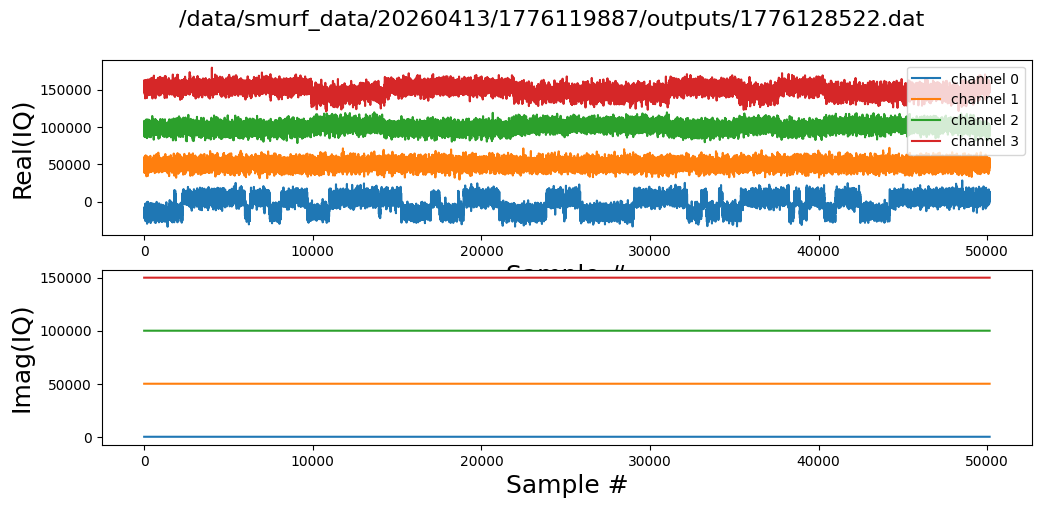

In [21]:
yoffset=50000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
for ch in range(len(d[0,:])):
    ych=bit_factor*d[:,ch]/accum_factor
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)
    ax1.plot(np.real(ych-ymedian) + yoffset*ch, label = f'channel {ch}')
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Sample #',fontsize=18)
    ax2.plot(np.imag(ych-ymedian) + yoffset*ch)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Sample #',fontsize=18)
    fig.suptitle(data_filename,fontsize=16)
    ax1.legend(loc = 'upper right')    
plt.show()

## Compare to data from SMuRF's native read_stream_data function:

In [17]:
import pysmurf.client
import epics
import os
import time

%matplotlib inline

epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

## Dump versions of everything
# Python version
print(sys.version)
import pysmurf
pysmurf.__version__
cwd=os.getcwd()
os.chdir('/usr/local/src/pysmurf/')
#print(str(!git branch))
#print(!git rev-parse --short HEAD)
print(S.get_fpga_git_hash_short())
print(S.config.filename)

[ 2026-04-16 20:28:38 ]  ERROR : band 0 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 1 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 2 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 3 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 4 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 5 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 6 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-16 20:28:38 ]  ERROR : band 7 is present in pysmurf cfg file, but its bay is not enabled!
3.8.10 (default, Mar 13 2023, 10:26:41) 
[GCC 9.4.0]
9355e2a
/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg


In [ ]:
t,d,m,h=S.read_stream_data(data_filename,return_header=True)

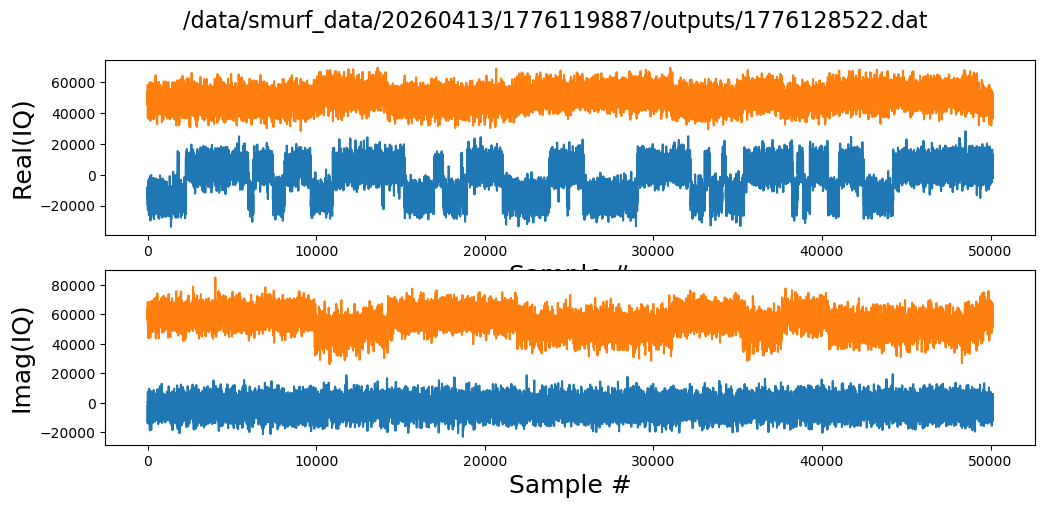

In [90]:
yoffset=50000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
for ch in range(2):
    ych=bit_factor*d[ch]/accum_factor
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)
    ax1.plot(np.real(ych-ymedian) + yoffset*ch)
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Sample #',fontsize=18)
    ax2.plot(np.imag(ych-ymedian) + yoffset*ch)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Sample #',fontsize=18)
    fig.suptitle(data_filename,fontsize=16)

In [31]:
h

{'protocol_version': array([3, 3, 3, ..., 3, 3, 3]),
 'crate_id': array([0, 0, 0, ..., 0, 0, 0]),
 'slot_number': array([0, 0, 0, ..., 0, 0, 0]),
 'timing_cond': array([0, 0, 0, ..., 0, 0, 0]),
 'number_of_channels': array([4, 4, 4, ..., 4, 4, 4]),
 'timestamp': array([1776128522573252654, 1776128522573482164, 1776128522573669625, ...,
        1776128532601703665, 1776128532601903971, 1776128532602104340]),
 'flux_ramp_increment': array([0, 0, 0, ..., 0, 0, 0]),
 'flux_ramp_offset': array([0, 0, 0, ..., 0, 0, 0]),
 'counter_0': array([0, 0, 0, ..., 0, 0, 0]),
 'counter_1': array([0, 0, 0, ..., 0, 0, 0]),
 'counter_2': array([0, 0, 0, ..., 0, 0, 0]),
 'reset_bits': array([0, 0, 0, ..., 0, 0, 0]),
 'frame_counter': array([39272930, 39272931, 39272932, ..., 39323072, 39323073, 39323074]),
 'tes_relays_config': array([0, 0, 0, ..., 0, 0, 0]),
 'external_time_raw': array([0, 0, 0, ..., 0, 0, 0]),
 'control_field': array([255, 255, 255, ..., 255, 255, 255]),
 'test_params': array([255, 255, 

In [20]:
times = h['timestamp']

In [21]:
np.gradient(times)

array([229632., 208512., 193152., ..., 199936., 200320., 200448.])

In [22]:
np.mean(np.gradient(times))

200001.33117957923

In [23]:
1/(np.mean(np.gradient(times)))

4.999966720732023e-06

In [24]:
1/(np.mean(np.gradient(times)) * 1e-9)

4999.966720732023

In [25]:
np.nonzero(h['external_time_raw'])

(array([], dtype=int64),)

## Testing my SMURF_import_funcs.py

In [10]:
from SMURF_import_funcs import *

In [11]:
d, h, m = read_file(data_filename)

first pass read to count frames
starting to scan file
at last byte
7629544 7629544
done scanning file
found {'num_data_frames': 50145, 'num_metadata_frames': 12, 'max_channels': 4, 'max_metadata_size': 732} in file


In [12]:
get_sample_rate(h)

5000.0

In [13]:
match_times(d, h)

array([0.00000e+00, 2.00000e-04, 4.00000e-04, ..., 1.00284e+01,
       1.00286e+01, 1.00288e+01])

In [14]:
d.shape

(50145, 4)

In [15]:
data_mag_phase = reformat_data(d)

In [16]:
print(data_mag_phase)

{'channel1': {'amps': array([0.00126966, 0.00129722, 0.00132577, ..., 0.00132683, 0.00131077,
       0.00130512]), 'phases': array([-1.47471706, -1.44706284, -1.41111621, ..., -1.21667441,
       -1.18963827, -1.17954747])}, 'channel2': {'amps': array([0.0004095 , 0.0004377 , 0.00048326, ..., 0.00048737, 0.00047487,
       0.00046484]), 'phases': array([1.8041662 , 1.88626129, 1.8929395 , ..., 1.75298057, 1.73985705,
       1.87785206])}}


In [17]:
f = ParityTimestream(filepath='/', filename=data_filename, plotpath='/plots/', DAQ_method = 'SMURF', channel_num = 1)

first pass read to count frames
starting to scan file
at last byte
7629544 7629544
done scanning file
found {'num_data_frames': 50145, 'num_metadata_frames': 12, 'max_channels': 4, 'max_metadata_size': 732} in file


In [18]:
print(f)

--------------------
  YYYYMMDD_HHMMSS
series: YYYYMMDD_HHMMSS
filename: /data/smurf_data/20260413/1776119887/outputs/1776128522.dat
filepath: /
DAQ_method: SMURF
channel_num: 1
sample_rate: 5000.0
psd_done: False
plotpath: /plots/
--------------------
 


{'threshold': 4.325098571353561e-17, 'threshold_axis': 'Q_rot', 'psd_freqs': array([0.00000000e+00, 1.22070312e+00, 2.44140625e+00, ...,
       2.49755859e+03, 2.49877930e+03, 2.50000000e+03]), 'psd_yvals': array([2.60385728e-35, 5.78578733e-04, 2.64174683e-04, ...,
       4.40306619e-08, 3.87994032e-08, 1.89963335e-08]), 'tel_cen': 4.325098571353561e-17, 'tel_sep': 0.006877004414486493, 'psd_corr_fit_S0': 0.005386556829251417, 'psd_corr_fit_F': 0.9999999999999791, 'psd_corr_fit_Gamma_p': 7.946935694371441, 'psd_corr_fit_delta_t': 0.0002, 'psd_corr_fit_pcov': array([[ 6.92818630e-06,  1.49664192e-07, -7.42333055e-03],
       [ 1.49664192e-07,  7.56022278e-08,  1.07005114e-03],
       [-7.42333055e-03,  1.07005114e-03,  3.09476307e+01]])}


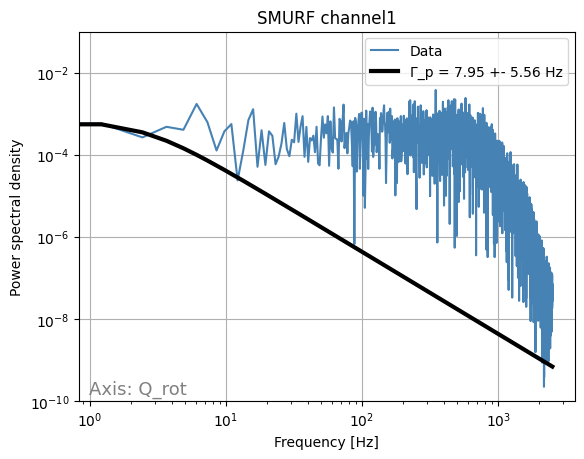

In [20]:
f.calc_psd(data_axis_label='Q_rot', nfft=2**12)
f.fit_psd()
f.plot_psd_fit(plot_title=None, ymin=1e-10, ymax=1e-1, savefig=False, plot_corrected_fit=True, plot_standard_fit=False)
print(f.analysis)

In [20]:
def corrected_lorentzian_psd(f, S0, F, Gamma_p, delta_t):
    """
    Lorentzian PSD with correction factor from  eq.14 of [https://arxiv.org/pdf/2402.15471]
    ----------------
    Args:
        f: frequency x-axis
        S0: zero frequency amplitude
        F: parity sequence mapping fidelity
        Gamma_p: parity switching rate
        delta_t: time between parity measurements
    Returns:
        Lorentzian function in frequency space
    """
    return S0 * ((4 * F**2 * Gamma_p) / ((2 * Gamma_p)**2 + (2 * np.pi * f)**2) + (1 - F**2) * delta_t)

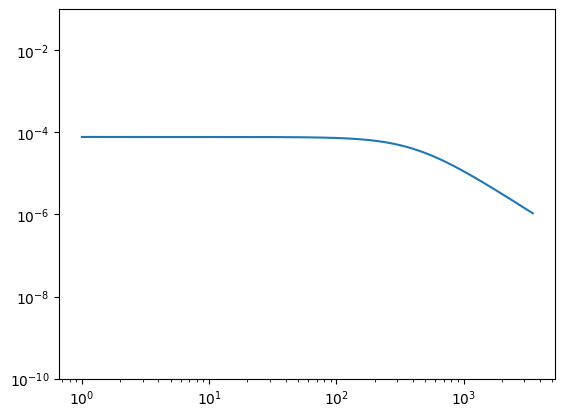

In [32]:
freqs = np.linspace(1, 3500, 1000)
S0 = 1e-1
F = .9999
Gamma_p = 1300
delta_t = 1 / (get_sample_rate(h) )

plt.figure()
plt.loglog(freqs, corrected_lorentzian_psd(freqs, S0, F, Gamma_p, delta_t))
plt.ylim([1e-10, 1e-1])
plt.show()